# Predicción de Miopía en Estudiantes de Medicina - VERSIÓN MEJORADA
## Universidad de Navarra

### Objetivo:
Predecir 4 variables relacionadas con la miopía:
1. **M**: Clasificación binaria (SI/NO) - ¿Tiene miopía?
2. **MM**: Clasificación binaria (SI/NO) - ¿Tiene miopía magna?
3. **COMBO**: Clasificación multi-clase (M, MM, C) - Tipo de condición
4. **DCOMBO**: Clasificación multi-clase (M1, M2, MM, C) - Clasificación detallada

### Mejoras Implementadas:
- ✅ Análisis Exploratorio de Datos (EDA) completo con visualizaciones
- ✅ Separación train/validation para evaluación real
- ✅ Múltiples métricas de evaluación (F1, Precision, Recall, ROC-AUC)
- ✅ Curvas ROC y Precision-Recall
- ✅ Optimización de hiperparámetros con GridSearchCV
- ✅ Análisis de importancia de features
- ✅ Guardado de modelos y transformadores
- ✅ Manejo robusto de valores faltantes y categorías desconocidas
- ✅ Análisis de errores y confusion matrices
- ✅ Validación de consistencia entre train y test

## 1. Importar Librerías Necesarias

In [1]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Librerías para preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Librerías para modelado
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Librerías para validación y métricas
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

# Configuración
import warnings
# Solo filtramos warnings específicos, no todos
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# Seed para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías importadas correctamente")
print(f"   Pandas: {pd.__version__}")
print(f"   NumPy: {np.__version__}")
print(f"   Random State: {RANDOM_STATE}")

✅ Librerías importadas correctamente
   Pandas: 2.3.1
   NumPy: 2.2.6
   Random State: 42


## 2. Cargar los Datos

In [2]:
# Cargar los conjuntos de datos
print("📂 Cargando datos...")
X_train = pd.read_csv('X_train.csv')
Y_train = pd.read_csv('Y_train.csv')
X_test = pd.read_csv('X_test.csv')

# Mostrar dimensiones
print(f"\n📊 Dimensiones de los datos:")
print(f"   Training features: {X_train.shape}")
print(f"   Training labels: {Y_train.shape}")
print(f"   Test features: {X_test.shape}")

# Validar consistencia de columnas
common_cols = set(X_train.columns) & set(X_test.columns)
only_train = set(X_train.columns) - set(X_test.columns)
only_test = set(X_test.columns) - set(X_train.columns)

print(f"\n🔍 Validación de consistencia:")
print(f"   Columnas comunes: {len(common_cols)}")
if only_train:
    print(f"   ⚠️ Solo en train: {only_train}")
if only_test:
    print(f"   ⚠️ Solo en test: {only_test}")
if not only_train and not only_test:
    print(f"   ✅ Columnas consistentes entre train y test")

print(f"\n🎯 Variables objetivo:")
for col in Y_train.columns:
    print(f"   • {col}")

📂 Cargando datos...

📊 Dimensiones de los datos:
   Training features: (132, 49)
   Training labels: (132, 4)
   Test features: (24, 49)

🔍 Validación de consistencia:
   Columnas comunes: 49
   ✅ Columnas consistentes entre train y test

🎯 Variables objetivo:
   • M
   • MM
   • Combo
   • DCombo


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Información General del Dataset

In [3]:
# Información del dataset
print("\n📋 Información del Training Set:")
print("="*80)
print(X_train.info())

# Primeras filas
print("\n📊 Primeras 3 filas del dataset:")
display(X_train.head(3))


📋 Información del Training Set:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   fecha                             132 non-null    object 
 1   edad                              132 non-null    int64  
 2   sexo                              132 non-null    object 
 3   origen antepasados (españa)       130 non-null    object 
 4   origen antepasados (extranjeros)  34 non-null     object 
 5   hº deporte sem                    132 non-null    float64
 6   hº naturaleza sem                 132 non-null    float64
 7   hº ocio exteriores sem            130 non-null    float64
 8   horas exterior sem                132 non-null    float64
 9   hº estudiar sem                   132 non-null    int64  
 10  hº ocio inter sem                 132 non-null    int64  
 11  hº act.cerca sem                  0 no

,fecha,edad,sexo,origen antepasados (españa),origen antepasados (extranjeros),hº deporte sem,hº naturaleza sem,hº ocio exteriores sem,horas exterior sem,hº estudiar sem,...,OS-DS,CUVAF-Total,CUVAF-Media,CUVAF-DS,Promedio Nasal,DE Nasal,Suma Nasal,Promedio Temporal,DE Temporal,Suma Temporal
0,2/11/20,22,Mujer,Asturias,NaN,0.0,0.0,4.0,4.0,40,...,0.238059,2.256667,0.564167,0.842300,0.905000,1.279863,1.810000,0.223333,0.160278,0.446667
1,2/17/20,23,Mujer,Navarra,NaN,5.0,2.0,2.0,9.0,20,...,2.585654,8.026667,2.006667,1.887316,3.620833,0.503224,7.241667,0.392500,0.102530,0.785000
2,3/10/20,22,Mujer,Bizkaia,NaN,2.0,3.0,8.0,13.0,30,...,0.431335,12.710000,3.177500,0.743668,3.152500,1.248043,6.305000,3.202500,0.314663,6.405000


### 3.2 Análisis de Valores Faltantes


⚠️ Columnas con valores faltantes: 10


,Columna,Missing,Porcentaje
hº act.cerca sem,hº act.cerca sem,132,100.00
origen antepasados (extranjeros),origen antepasados (extranjeros),98,74.24
Grupo fot,Grupo fot,24,18.18
fototipo,fototipo,21,15.91
Familiar miope num.,Familiar miope num.,4,3.03
origen antepasados (españa),origen antepasados (españa),2,1.52
pat. Ret. Miop magna,pat. Ret. Miop magna,2,1.52
hº ocio exteriores sem,hº ocio exteriores sem,2,1.52
horas interior sem,horas interior sem,1,0.76
familiar miope,familiar miope,1,0.76


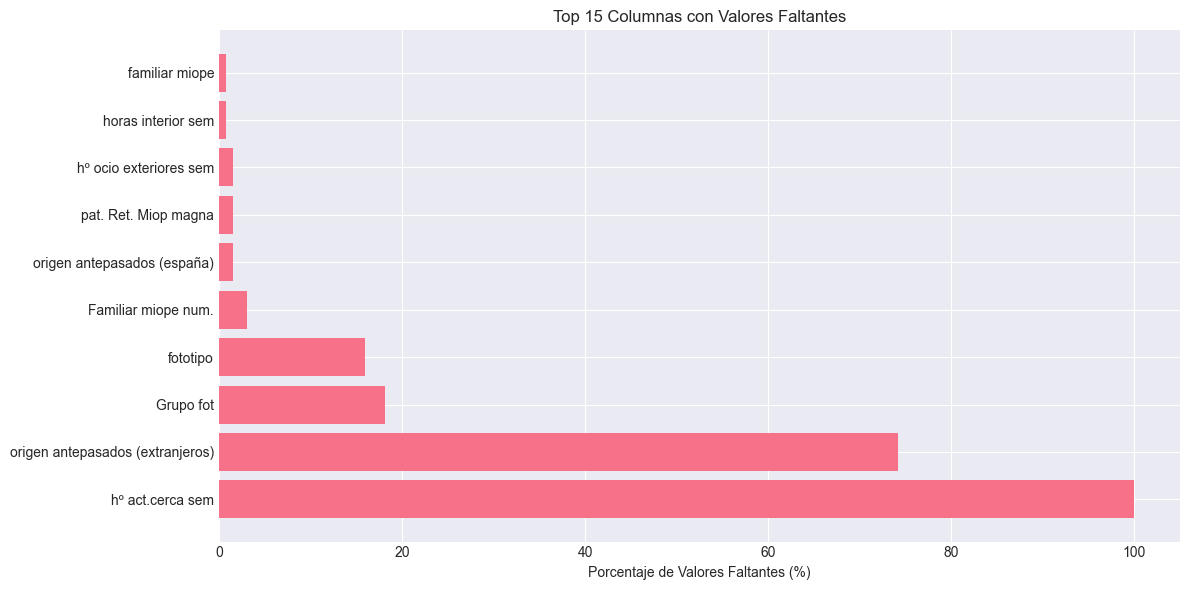

In [4]:
# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Columna': X_train.columns,
    'Missing': X_train.isnull().sum(),
    'Porcentaje': (X_train.isnull().sum() / len(X_train) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_data) > 0:
    print(f"\n⚠️ Columnas con valores faltantes: {len(missing_data)}")
    print("="*80)
    display(missing_data.head(20))
    
    # Visualizar
    if len(missing_data) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        top_missing = missing_data.head(15)
        ax.barh(top_missing['Columna'], top_missing['Porcentaje'])
        ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
        ax.set_title('Top 15 Columnas con Valores Faltantes')
        plt.tight_layout()
        plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

### 3.3 Distribución de Variables Objetivo


📊 Distribución de Variables Objetivo:

M:
   • SI: 88 (66.67%)
   • NO: 44 (33.33%)

MM:
   • NO: 122 (92.42%)
   • SI: 10 (7.58%)

Combo:
   • M: 70 (53.03%)
   • C: 44 (33.33%)
   • MM: 18 (13.64%)

DCombo:
   • C: 44 (33.33%)
   • M1: 39 (29.55%)
   • M2: 31 (23.48%)
   • MM: 18 (13.64%)


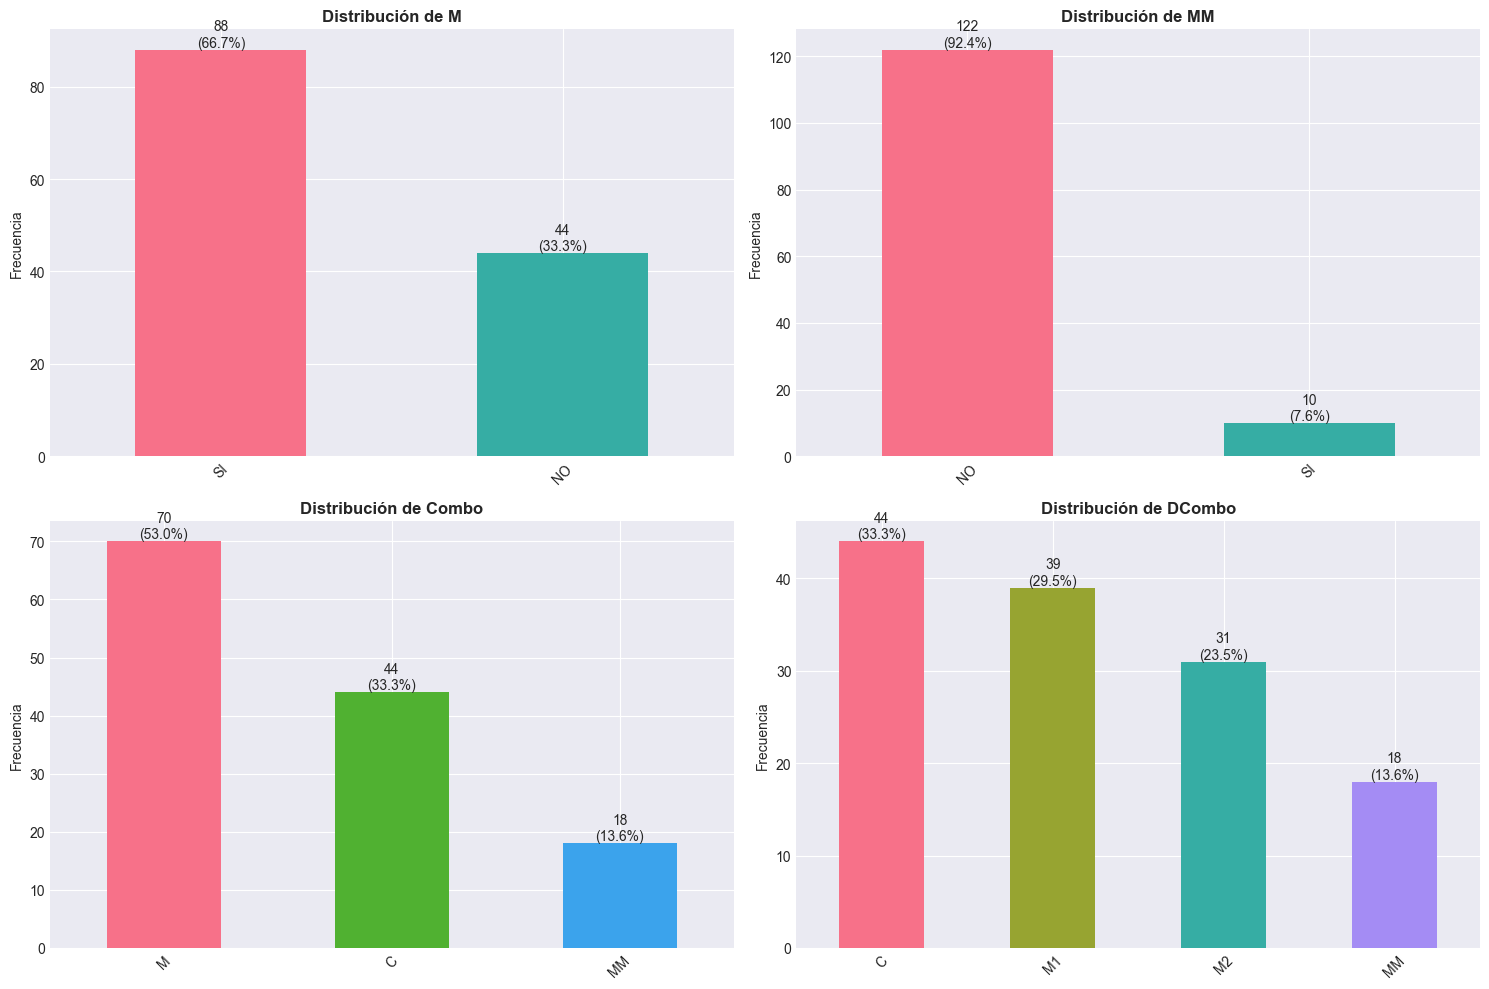


⚠️ Nota sobre desbalanceo de clases:
   Se usará class_weight='balanced' en los modelos para manejar esto.


In [5]:
# Distribución de clases
print("\n📊 Distribución de Variables Objetivo:")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(Y_train.columns):
    # Contar valores
    value_counts = Y_train[col].value_counts()
    print(f"\n{col}:")
    for val, count in value_counts.items():
        pct = count / len(Y_train) * 100
        print(f"   • {val}: {count} ({pct:.2f}%)")
    
    # Visualizar
    value_counts.plot(kind='bar', ax=axes[idx], color=sns.color_palette('husl', len(value_counts)))
    axes[idx].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Añadir porcentajes en las barras
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v, f'{v}\n({v/len(Y_train)*100:.1f}%)', 
                      ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n⚠️ Nota sobre desbalanceo de clases:")
print("   Se usará class_weight='balanced' en los modelos para manejar esto.")

### 3.4 Análisis de Variables Numéricas

In [6]:
# Identificar columnas numéricas (excluyendo fecha)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📊 Estadísticas de Variables Numéricas ({len(numeric_cols)} columnas):")
print("="*80)
display(X_train[numeric_cols].describe().T)


📊 Estadísticas de Variables Numéricas (33 columnas):


,count,mean,std,min,25%,50%,75%,max
edad,132.0,22.371212,0.859658,20.00,22.000000,22.000000,23.000000,25.000000
hº deporte sem,132.0,3.954545,3.543328,0.00,1.000000,3.000000,6.000000,18.000000
hº naturaleza sem,132.0,1.768939,2.964423,0.00,0.000000,1.000000,3.000000,22.000000
hº ocio exteriores sem,130.0,3.584615,3.978205,0.00,0.000000,2.000000,5.000000,21.000000
horas exterior sem,132.0,9.253788,6.667254,0.00,4.875000,8.000000,12.250000,42.000000
hº estudiar sem,132.0,38.742424,15.090881,5.00,30.000000,40.000000,50.000000,80.000000
hº ocio inter sem,132.0,19.795455,14.466987,0.00,10.000000,15.000000,28.000000,80.000000
hº act.cerca sem,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horas interior sem,131.0,58.587786,21.936927,8.00,45.000000,57.000000,65.500000,140.000000
Ratio Cerca/Lejos,132.0,12.413300,16.635364,0.00,4.262500,6.619048,14.029412,126.000000


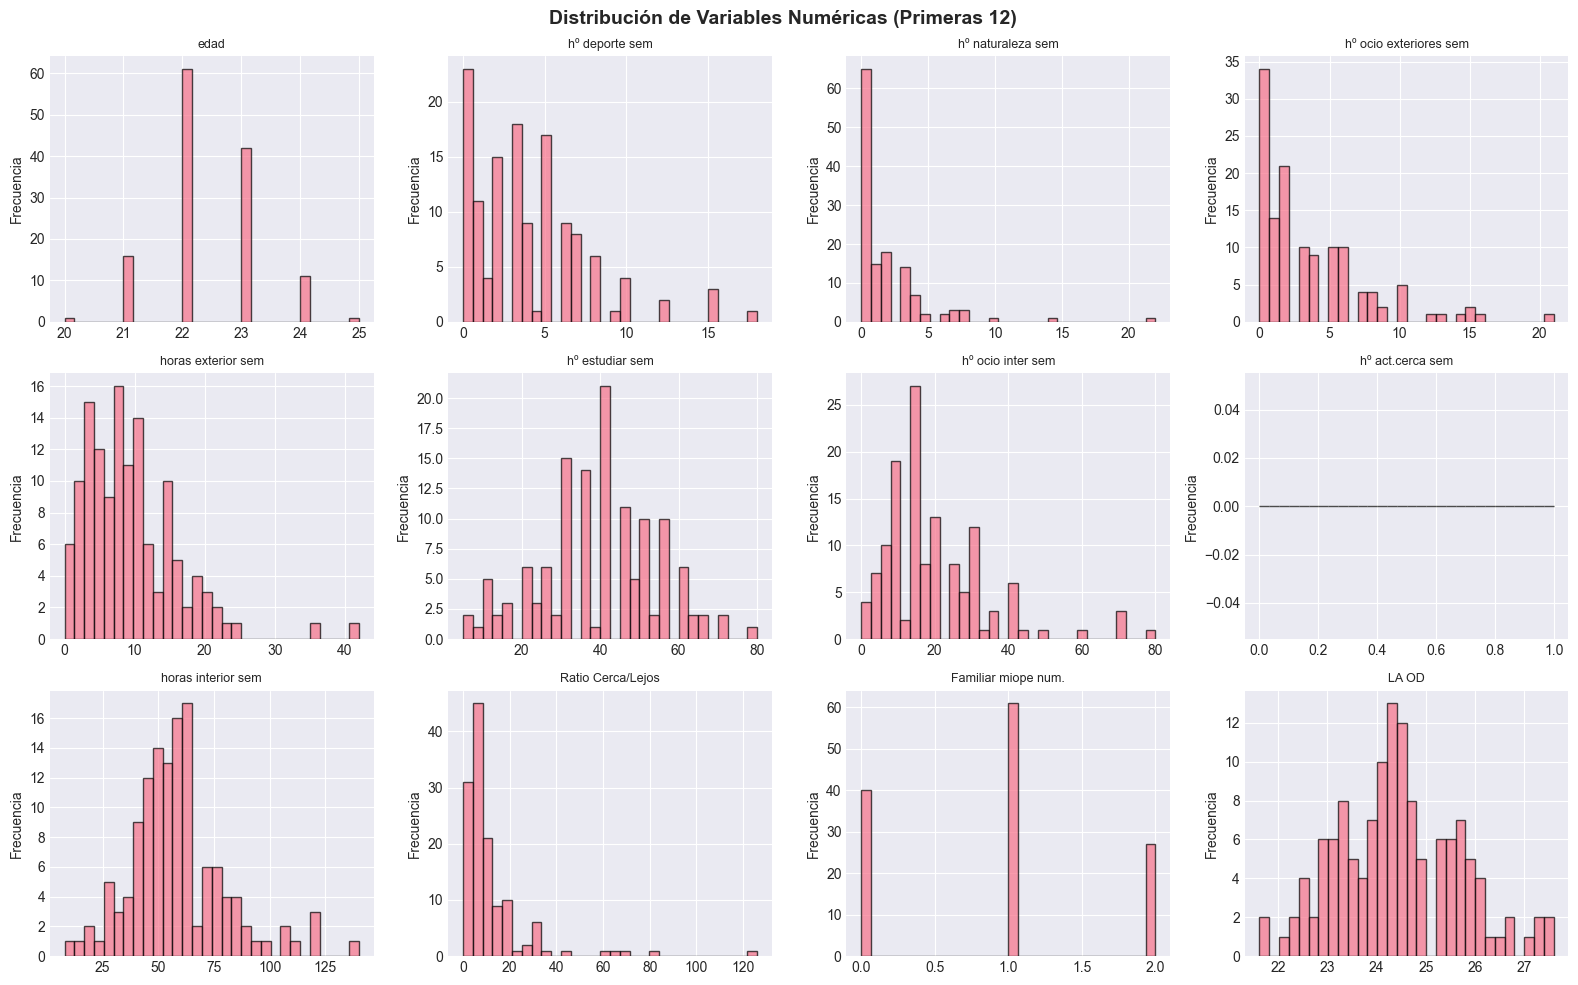

In [7]:
# Visualizar distribuciones de algunas variables importantes
# Seleccionar primeras 12 variables numéricas para visualizar
cols_to_plot = numeric_cols[:12] if len(numeric_cols) >= 12 else numeric_cols

if len(cols_to_plot) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.ravel()

    for idx, col in enumerate(cols_to_plot):
        axes[idx].hist(X_train[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(col, fontsize=9)
        axes[idx].set_ylabel('Frecuencia')

    # Ocultar ejes sobrantes
    for idx in range(len(cols_to_plot), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Distribución de Variables Numéricas (Primeras 12)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 3.5 Análisis de Variables Categóricas

In [8]:
# Identificar columnas categóricas
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
# Excluir 'fecha' si existe
categorical_cols = [col for col in categorical_cols if col != 'fecha']

print(f"\n📊 Variables Categóricas ({len(categorical_cols)} columnas):")
print("="*80)

for col in categorical_cols:
    n_unique = X_train[col].nunique()
    print(f"\n{col}: {n_unique} categorías únicas")
    if n_unique <= 10:
        print(X_train[col].value_counts())
        print("-" * 40)
    else:
        print(f"   Top 5 categorías:")
        print(X_train[col].value_counts().head())
        print("-" * 40)


📊 Variables Categóricas (15 columnas):

sexo: 2 categorías únicas
sexo
Mujer     97
Hombre    35
Name: count, dtype: int64
----------------------------------------

origen antepasados (españa): 79 categorías únicas
   Top 5 categorías:
origen antepasados (españa)
Navarra      28
Bizkaia       5
Madrid        5
Barcelona     4
Alicante      3
Name: count, dtype: int64
----------------------------------------

origen antepasados (extranjeros): 15 categorías únicas
   Top 5 categorías:
origen antepasados (extranjeros)
España       17
No            2
Portugal      2
Francia       2
Filipinas     1
Name: count, dtype: int64
----------------------------------------

Exterior Mucho: 2 categorías únicas
Exterior Mucho
NO    69
SI    63
Name: count, dtype: int64
----------------------------------------

Interior Mcho: 2 categorías únicas
Interior Mcho
NO    124
SI      8
Name: count, dtype: int64
----------------------------------------

fototipo: 7 categorías únicas
fototipo
E             36


### 3.6 Matriz de Correlación


🔗 Matriz de Correlación (primeras 20 variables numéricas):


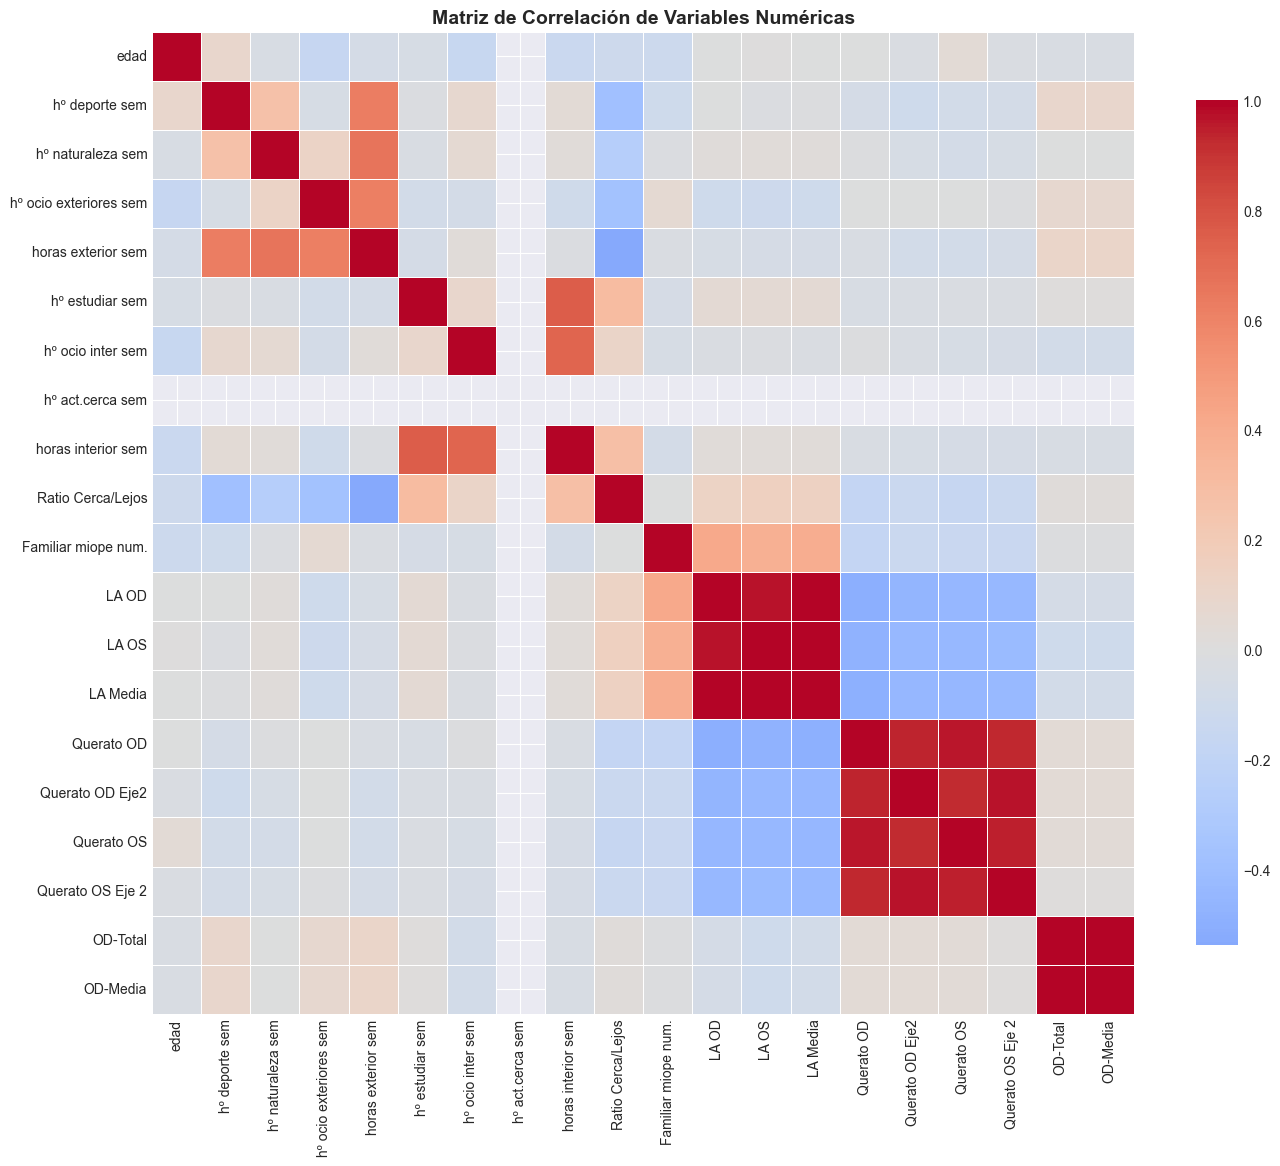


🔍 Correlaciones altas (|r| > 0.8, excluyendo diagonales):
   • OD-Total <-> OD-Media: 1.000
   • LA OS <-> LA Media: 0.993
   • LA OD <-> LA Media: 0.993
   • LA OD <-> LA OS: 0.973
   • Querato OD Eje2 <-> Querato OS Eje 2: 0.968
   • Querato OD <-> Querato OS: 0.962
   • Querato OS <-> Querato OS Eje 2: 0.945
   • Querato OD <-> Querato OD Eje2: 0.938
   • Querato OD <-> Querato OS Eje 2: 0.930
   • Querato OD Eje2 <-> Querato OS: 0.926


In [9]:
# Calcular correlación solo para variables numéricas
# Seleccionar un subconjunto si hay demasiadas columnas
numeric_for_corr = numeric_cols[:20] if len(numeric_cols) > 20 else numeric_cols

if len(numeric_for_corr) > 0:
    print(f"\n🔗 Matriz de Correlación (primeras {len(numeric_for_corr)} variables numéricas):")
    corr_matrix = X_train[numeric_for_corr].corr()

    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Encontrar correlaciones altas
    print("\n🔍 Correlaciones altas (|r| > 0.8, excluyendo diagonales):")
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.8:
                high_corr.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    
    if high_corr:
        for col1, col2, corr_val in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f"   • {col1} <-> {col2}: {corr_val:.3f}")
    else:
        print("   No se encontraron correlaciones > 0.8")

## 4. Preprocesamiento de Datos Robusto

### 4.1 Clase de Preprocesamiento Mejorada

In [10]:
class DataPreprocessor:
    """
    Preprocesador robusto que guarda todos los transformadores
    para aplicar consistentemente a train, validation y test.
    
    Mejoras:
    - Guarda imputadores entrenados para valores faltantes
    - Guarda label encoders para variables categóricas
    - Maneja categorías desconocidas de forma robusta
    - Valida consistencia de columnas
    - Exportable/importable con pickle
    """
    
    def __init__(self):
        self.numeric_imputer = None
        self.categorical_imputer = None
        self.label_encoders = {}
        self.numeric_cols = None
        self.categorical_cols = None
        self.feature_names = None
        self.is_fitted = False
        
    def fit(self, X):
        """Entrena todos los transformadores con el conjunto de entrenamiento"""
        X_copy = X.copy()
        
        # 1. Eliminar columna fecha si existe
        if 'fecha' in X_copy.columns:
            X_copy = X_copy.drop('fecha', axis=1)
            print("   ✓ Columna 'fecha' eliminada")
        
        # 2. Identificar tipos de columnas
        self.numeric_cols = X_copy.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = X_copy.select_dtypes(include=['object']).columns.tolist()
        self.feature_names = X_copy.columns.tolist()
        
        print(f"   ✓ Columnas numéricas: {len(self.numeric_cols)}")
        print(f"   ✓ Columnas categóricas: {len(self.categorical_cols)}")
        
        # 3. Entrenar imputador numérico (mediana)
        if self.numeric_cols:
            self.numeric_imputer = SimpleImputer(strategy='median')
            self.numeric_imputer.fit(X_copy[self.numeric_cols])
            print(f"   ✓ Imputador numérico entrenado (mediana)")
        
        # 4. Entrenar label encoders para categóricas
        for col in self.categorical_cols:
            # Rellenar NaN con 'Missing'
            values = X_copy[col].fillna('Missing').astype(str)
            
            le = LabelEncoder()
            le.fit(values)
            self.label_encoders[col] = le
        
        if self.categorical_cols:
            print(f"   ✓ Label encoders entrenados para {len(self.categorical_cols)} variables")
        
        self.is_fitted = True
        return self
    
    def transform(self, X):
        """Transforma datos usando los transformadores entrenados"""
        if not self.is_fitted:
            raise ValueError("El preprocesador debe ser entrenado primero con fit()")
        
        X_copy = X.copy()
        
        # 1. Eliminar fecha
        if 'fecha' in X_copy.columns:
            X_copy = X_copy.drop('fecha', axis=1)
        
        # 2. Validar columnas
        missing_cols = set(self.feature_names) - set(X_copy.columns)
        extra_cols = set(X_copy.columns) - set(self.feature_names)
        
        if missing_cols:
            print(f"   ⚠️ Columnas faltantes: {missing_cols}")
            # Añadir con NaN
            for col in missing_cols:
                X_copy[col] = np.nan
        
        if extra_cols:
            print(f"   ⚠️ Columnas extra (se eliminarán): {extra_cols}")
            X_copy = X_copy.drop(columns=extra_cols)
        
        # Reordenar columnas para consistencia
        X_copy = X_copy[self.feature_names]
        
        # 3. Imputar valores numéricos
        if self.numeric_cols and self.numeric_imputer:
            X_copy[self.numeric_cols] = self.numeric_imputer.transform(X_copy[self.numeric_cols])
            
            # Reemplazar infinitos
            for col in self.numeric_cols:
                X_copy[col] = X_copy[col].replace([np.inf, -np.inf], 0)
        
        # 4. Codificar variables categóricas
        for col in self.categorical_cols:
            # Rellenar NaN
            X_copy[col] = X_copy[col].fillna('Missing').astype(str)
            
            le = self.label_encoders[col]
            
            # Manejar categorías no vistas: usar un valor especial
            # En lugar de -1, usar el índice de 'Missing' o el máximo + 1
            unknown_value = len(le.classes_)
            
            X_copy[col] = X_copy[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else unknown_value
            )
        
        # 5. Limpieza final
        X_copy = X_copy.fillna(0)
        
        return X_copy
    
    def fit_transform(self, X):
        """Entrena y transforma en un solo paso"""
        return self.fit(X).transform(X)
    
    def save(self, filepath):
        """Guarda el preprocesador en disco"""
        with open(filepath, 'wb') as f:
            pickle.dump(self, f)
        print(f"   ✓ Preprocesador guardado en: {filepath}")
    
    @staticmethod
    def load(filepath):
        """Carga un preprocesador desde disco"""
        with open(filepath, 'rb') as f:
            preprocessor = pickle.load(f)
        print(f"   ✓ Preprocesador cargado desde: {filepath}")
        return preprocessor

print("✅ Clase DataPreprocessor definida")

✅ Clase DataPreprocessor definida


### 4.2 Aplicar Preprocesamiento

In [11]:
print("\n📝 Aplicando preprocesamiento...")
print("="*80)

# Crear y entrenar preprocesador
print("\n1. Entrenando preprocesador con datos de TRAINING:")
preprocessor = DataPreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)

# Transformar conjunto de test
print("\n2. Aplicando preprocesador a datos de TEST:")
X_test_proc = preprocessor.transform(X_test)

print(f"\n✅ Preprocesamiento completado")
print(f"   Training: {X_train_proc.shape}")
print(f"   Test: {X_test_proc.shape}")

# Guardar preprocesador
preprocessor.save('preprocessor.pkl')


📝 Aplicando preprocesamiento...

1. Entrenando preprocesador con datos de TRAINING:
   ✓ Columna 'fecha' eliminada
   ✓ Columnas numéricas: 33
   ✓ Columnas categóricas: 15
   ✓ Imputador numérico entrenado (mediana)
   ✓ Label encoders entrenados para 15 variables


ValueError: Columns must be same length as key

### 4.3 Separar Conjunto de Validación

In [ ]:
print("\n📊 Creando conjunto de VALIDACIÓN (20% del training):")
print("="*80)

# Separar train/validation estratificado por TODAS las etiquetas
# Usamos la primera columna para estratificar (M) como proxy
X_train_split, X_val_split, Y_train_split, Y_val_split = train_test_split(
    X_train_proc,
    Y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=Y_train['M']  # Estratificar por la variable principal
)

print(f"\n✅ División completada:")
print(f"   Training: {X_train_split.shape}")
print(f"   Validation: {X_val_split.shape}")

# Verificar distribución en validación
print(f"\n📊 Distribución en conjunto de validación:")
for col in Y_val_split.columns:
    print(f"\n   {col}:")
    val_counts = Y_val_split[col].value_counts()
    for val, count in val_counts.items():
        pct = count / len(Y_val_split) * 100
        print(f"      • {val}: {count} ({pct:.2f}%)")

### 4.4 Estandarización

In [ ]:
print("\n📐 Estandarizando características (media=0, std=1):")
print("="*80)

# Crear estandarizador
scaler = StandardScaler()

# Entrenar SOLO con training y transformar train/val/test
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test_proc)

print(f"\n✅ Estandarización completada")
print(f"   Media del training: {X_train_scaled.mean():.6f}")
print(f"   Std del training: {X_train_scaled.std():.6f}")
print(f"   Media del validation: {X_val_scaled.mean():.6f}")
print(f"   Std del validation: {X_val_scaled.std():.6f}")

# Guardar scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n✓ Scaler guardado en: scaler.pkl")

## 5. Configuración de Modelos con Optimización de Hiperparámetros

### 5.1 Definir Grids de Hiperparámetros

In [ ]:
# Definir grids de búsqueda para cada modelo
# Usamos grids pequeños para que no tarde demasiado

param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [100, 150],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear']
        }
    }
}

print("✅ Grids de hiperparámetros definidos")
print("\nModelos a evaluar:")
for name in param_grids.keys():
    n_combinations = np.prod([len(v) for v in param_grids[name]['params'].values()])
    print(f"   • {name}: {n_combinations} combinaciones")

### 5.2 Función de Entrenamiento y Evaluación Completa

In [ ]:
def train_and_evaluate_model(X_train, y_train, X_val, y_val, label_name, param_grids):
    """
    Entrena múltiples modelos con GridSearchCV y evalúa en validación.
    
    Retorna:
    - best_model: Mejor modelo entrenado
    - results: Diccionario con todas las métricas
    """
    print(f"\n{'='*80}")
    print(f"🎯 ENTRENANDO MODELOS PARA: {label_name}")
    print(f"{'='*80}")
    
    results = {}
    
    # Determinar si es binario o multi-clase
    n_classes = len(np.unique(y_train))
    is_binary = n_classes == 2
    
    print(f"\nTipo de problema: {'Binario' if is_binary else 'Multi-clase'} ({n_classes} clases)")
    
    # Configurar scoring para GridSearch
    scoring = 'f1' if is_binary else 'f1_macro'
    
    # Entrenar cada modelo
    for model_name, config in param_grids.items():
        print(f"\n{'─'*80}")
        print(f"📊 {model_name}")
        print(f"{'─'*80}")
        
        # GridSearchCV con validación cruzada estratificada
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
            scoring=scoring,
            n_jobs=-1,
            verbose=0
        )
        
        # Entrenar
        print("   Buscando mejores hiperparámetros...")
        grid_search.fit(X_train, y_train)
        
        # Mejor modelo
        best_model = grid_search.best_estimator_
        
        print(f"   ✓ Mejores parámetros: {grid_search.best_params_}")
        print(f"   ✓ Mejor CV score: {grid_search.best_score_:.4f}")
        
        # Predecir en validación
        y_pred = best_model.predict(X_val)
        
        # Calcular métricas
        accuracy = accuracy_score(y_val, y_pred)
        
        if is_binary:
            precision = precision_score(y_val, y_pred, pos_label='SI', zero_division=0)
            recall = recall_score(y_val, y_pred, pos_label='SI', zero_division=0)
            f1 = f1_score(y_val, y_pred, pos_label='SI', zero_division=0)
        else:
            precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
        
        # Guardar resultados
        results[model_name] = {
            'model': best_model,
            'best_params': grid_search.best_params_,
            'cv_score': grid_search.best_score_,
            'val_accuracy': accuracy,
            'val_precision': precision,
            'val_recall': recall,
            'val_f1': f1,
            'y_pred': y_pred
        }
        
        # Mostrar métricas
        print(f"\n   📊 Métricas en Validación:")
        print(f"      • Accuracy:  {accuracy:.4f}")
        print(f"      • Precision: {precision:.4f}")
        print(f"      • Recall:    {recall:.4f}")
        print(f"      • F1-Score:  {f1:.4f}")
    
    # Seleccionar mejor modelo por F1-score
    best_model_name = max(results, key=lambda x: results[x]['val_f1'])
    best_result = results[best_model_name]
    
    print(f"\n{'='*80}")
    print(f"✨ MEJOR MODELO: {best_model_name}")
    print(f"   F1-Score en validación: {best_result['val_f1']:.4f}")
    print(f"{'='*80}")
    
    return best_result['model'], results, best_model_name

print("\n✅ Función de entrenamiento definida")

## 6. Entrenamiento de Modelos para Cada Etiqueta

In [ ]:
# Entrenar modelos para cada etiqueta
print("\n" + "="*80)
print("INICIO DEL ENTRENAMIENTO DE TODOS LOS MODELOS")
print("="*80)

# Diccionarios para guardar modelos y resultados
trained_models = {}
all_results = {}
best_model_names = {}

# Entrenar para cada etiqueta
for label in Y_train.columns:
    best_model, results, best_name = train_and_evaluate_model(
        X_train_scaled,
        Y_train_split[label].values,
        X_val_scaled,
        Y_val_split[label].values,
        label,
        param_grids
    )
    
    trained_models[label] = best_model
    all_results[label] = results
    best_model_names[label] = best_name

print("\n" + "="*80)
print("✅ ENTRENAMIENTO COMPLETADO PARA TODAS LAS ETIQUETAS")
print("="*80)

## 7. Evaluación Detallada en Validación

### 7.1 Resumen de Modelos Seleccionados

In [ ]:
# Crear tabla resumen
print("\n📊 RESUMEN DE MEJORES MODELOS:")
print("="*80)

summary_data = []
for label in Y_train.columns:
    best_name = best_model_names[label]
    best_res = all_results[label][best_name]
    
    summary_data.append({
        'Etiqueta': label,
        'Modelo': best_name,
        'Accuracy': f"{best_res['val_accuracy']:.4f}",
        'Precision': f"{best_res['val_precision']:.4f}",
        'Recall': f"{best_res['val_recall']:.4f}",
        'F1-Score': f"{best_res['val_f1']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

### 7.2 Confusion Matrices

In [ ]:
# Visualizar confusion matrices para todos los modelos
print("\n📊 CONFUSION MATRICES:")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, label in enumerate(Y_train.columns):
    best_name = best_model_names[label]
    y_pred = all_results[label][best_name]['y_pred']
    
    # Crear confusion matrix
    cm = confusion_matrix(Y_val_split[label], y_pred)
    
    # Visualizar
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=np.unique(Y_val_split[label]))
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{label} - {best_name}', fontsize=12, fontweight='bold')
    axes[idx].grid(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
print("   ✓ Gráfico guardado: confusion_matrices.png")
plt.show()

### 7.3 Classification Reports

In [ ]:
# Mostrar classification reports detallados
print("\n📋 CLASSIFICATION REPORTS DETALLADOS:")
print("="*80)

for label in Y_train.columns:
    best_name = best_model_names[label]
    y_pred = all_results[label][best_name]['y_pred']
    
    print(f"\n{'─'*80}")
    print(f"📊 {label} ({best_name})")
    print(f"{'─'*80}")
    print(classification_report(Y_val_split[label], y_pred, zero_division=0))

### 7.4 Curvas ROC (Para variables binarias)

In [ ]:
# Curvas ROC para variables binarias (M y MM)
print("\n📈 CURVAS ROC (Variables Binarias):")
print("="*80)

binary_labels = ['M', 'MM']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, label in enumerate(binary_labels):
    if label not in Y_train.columns:
        continue
    
    best_name = best_model_names[label]
    model = trained_models[label]
    
    # Obtener probabilidades
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val_scaled)
        
        # Convertir etiquetas a binario (SI=1, NO=0)
        y_true_binary = (Y_val_split[label] == 'SI').astype(int)
        
        # Calcular ROC
        fpr, tpr, thresholds = roc_curve(y_true_binary, y_proba[:, 1])
        roc_auc = roc_auc_score(y_true_binary, y_proba[:, 1])
        
        # Plotear
        axes[idx].plot(fpr, tpr, linewidth=2, label=f'{best_name} (AUC = {roc_auc:.3f})')
        axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
        axes[idx].set_xlabel('False Positive Rate', fontsize=11)
        axes[idx].set_ylabel('True Positive Rate', fontsize=11)
        axes[idx].set_title(f'ROC Curve - {label}', fontsize=12, fontweight='bold')
        axes[idx].legend(loc='lower right')
        axes[idx].grid(True, alpha=0.3)
        
        print(f"   • {label}: AUC = {roc_auc:.4f}")
    else:
        axes[idx].text(0.5, 0.5, f'Modelo {best_name}\nno soporta\npredict_proba', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'ROC Curve - {label}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
print("\n   ✓ Gráfico guardado: roc_curves.png")
plt.show()

### 7.5 Curvas Precision-Recall

In [ ]:
# Curvas Precision-Recall para variables binarias
print("\n📈 CURVAS PRECISION-RECALL (Variables Binarias):")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, label in enumerate(binary_labels):
    if label not in Y_train.columns:
        continue
    
    best_name = best_model_names[label]
    model = trained_models[label]
    
    # Obtener probabilidades
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val_scaled)
        
        # Convertir etiquetas a binario
        y_true_binary = (Y_val_split[label] == 'SI').astype(int)
        
        # Calcular Precision-Recall
        precision, recall, thresholds = precision_recall_curve(y_true_binary, y_proba[:, 1])
        avg_precision = average_precision_score(y_true_binary, y_proba[:, 1])
        
        # Plotear
        axes[idx].plot(recall, precision, linewidth=2, 
                      label=f'{best_name} (AP = {avg_precision:.3f})')
        axes[idx].axhline(y=y_true_binary.mean(), color='k', linestyle='--', 
                         linewidth=1, label=f'Baseline (AP = {y_true_binary.mean():.3f})')
        axes[idx].set_xlabel('Recall', fontsize=11)
        axes[idx].set_ylabel('Precision', fontsize=11)
        axes[idx].set_title(f'Precision-Recall Curve - {label}', fontsize=12, fontweight='bold')
        axes[idx].legend(loc='best')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim([0.0, 1.0])
        axes[idx].set_ylim([0.0, 1.05])
        
        print(f"   • {label}: Average Precision = {avg_precision:.4f}")
    else:
        axes[idx].text(0.5, 0.5, f'Modelo {best_name}\nno soporta\npredict_proba', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'PR Curve - {label}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
print("\n   ✓ Gráfico guardado: precision_recall_curves.png")
plt.show()

## 8. Análisis de Importancia de Features

### 8.1 Feature Importance para Random Forest y Gradient Boosting

In [ ]:
# Analizar importancia de features para modelos basados en árboles
print("\n🔍 ANÁLISIS DE IMPORTANCIA DE FEATURES:")
print("="*80)

feature_names = preprocessor.feature_names

for label in Y_train.columns:
    model = trained_models[label]
    
    # Solo para modelos con feature_importances_
    if hasattr(model, 'feature_importances_'):
        print(f"\n{'─'*80}")
        print(f"📊 {label} - {best_model_names[label]}")
        print(f"{'─'*80}")
        
        # Obtener importancias
        importances = model.feature_importances_
        
        # Crear DataFrame
        feature_imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        # Top 15 features
        print("\nTop 15 Features Más Importantes:")
        display(feature_imp_df.head(15))
        
        # Visualizar
        plt.figure(figsize=(10, 6))
        top_features = feature_imp_df.head(15)
        plt.barh(range(len(top_features)), top_features['Importance'])
        plt.yticks(range(len(top_features)), top_features['Feature'])
        plt.xlabel('Importancia')
        plt.title(f'Top 15 Features - {label}', fontsize=12, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'feature_importance_{label}.png', dpi=150, bbox_inches='tight')
        print(f"   ✓ Gráfico guardado: feature_importance_{label}.png")
        plt.show()

## 9. Análisis de Errores

### 9.1 Casos Mal Clasificados

In [ ]:
# Analizar casos mal clasificados
print("\n🔍 ANÁLISIS DE ERRORES:")
print("="*80)

for label in Y_train.columns:
    print(f"\n{'─'*80}")
    print(f"📊 {label}")
    print(f"{'─'*80}")
    
    best_name = best_model_names[label]
    y_pred = all_results[label][best_name]['y_pred']
    y_true = Y_val_split[label].values
    
    # Encontrar errores
    errors = y_pred != y_true
    n_errors = errors.sum()
    error_rate = n_errors / len(y_true) * 100
    
    print(f"\nTotal de errores: {n_errors} / {len(y_true)} ({error_rate:.2f}%)")
    
    # Análisis por clase
    print("\nErrores por clase:")
    for true_class in np.unique(y_true):
        mask = (y_true == true_class)
        class_errors = errors[mask].sum()
        class_total = mask.sum()
        class_error_rate = class_errors / class_total * 100 if class_total > 0 else 0
        
        print(f"   • {true_class}: {class_errors}/{class_total} errores ({class_error_rate:.2f}%)")
        
        # Mostrar a qué clases se confunde
        if class_errors > 0:
            confused_with = y_pred[mask & errors]
            confusion_counts = pd.Series(confused_with).value_counts()
            print(f"     Confundido con:")
            for conf_class, count in confusion_counts.items():
                print(f"       - {conf_class}: {count} veces")

## 10. Re-entrenar con TODO el Training Set

Ahora que hemos evaluado los modelos, re-entrenaremos con train+validation para maximizar el rendimiento.

In [ ]:
print("\n🔄 RE-ENTRENANDO MEJORES MODELOS CON TODO EL TRAINING SET:")
print("="*80)

# Combinar train y validation
X_full_train = np.vstack([X_train_scaled, X_val_scaled])
Y_full_train = pd.concat([Y_train_split, Y_val_split], axis=0)

print(f"\nDatos completos de entrenamiento: {X_full_train.shape}")

# Re-entrenar cada modelo con sus mejores hiperparámetros
final_models = {}

for label in Y_train.columns:
    print(f"\n   🎯 Re-entrenando modelo para {label}...")
    
    # Obtener el mejor modelo y sus parámetros
    best_name = best_model_names[label]
    best_params = all_results[label][best_name]['best_params']
    
    # Crear modelo con mejores parámetros
    base_model = param_grids[best_name]['model']
    final_model = base_model.set_params(**best_params)
    
    # Entrenar con todos los datos
    final_model.fit(X_full_train, Y_full_train[label].values)
    
    final_models[label] = final_model
    print(f"      ✓ {best_name} entrenado con {len(X_full_train)} muestras")

print("\n✅ Todos los modelos finales entrenados")

## 11. Predicciones en el Conjunto de Test

In [ ]:
print("\n🔮 GENERANDO PREDICCIONES PARA EL CONJUNTO DE TEST:")
print("="*80)

# Generar predicciones
predictions = {}

for label in Y_train.columns:
    model = final_models[label]
    pred = model.predict(X_test_scaled)
    predictions[label] = pred
    print(f"   ✓ Predicciones generadas para {label}")

# Crear DataFrame
predictions_df = pd.DataFrame(predictions)

print(f"\n✅ Todas las predicciones generadas")
print(f"   Forma: {predictions_df.shape}")

# Mostrar distribución
print("\n📊 Distribución de predicciones:")
for col in predictions_df.columns:
    print(f"\n   {col}:")
    for val, count in predictions_df[col].value_counts().items():
        pct = count / len(predictions_df) * 100
        print(f"      • {val}: {count} ({pct:.2f}%)")

## 12. Guardar Modelos y Resultados

In [ ]:
print("\n💾 GUARDANDO MODELOS Y RESULTADOS:")
print("="*80)

# Crear carpeta para modelos
Path('models').mkdir(exist_ok=True)

# Guardar cada modelo
for label, model in final_models.items():
    model_path = f'models/model_{label}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"   ✓ Modelo guardado: {model_path}")

# Guardar información de modelos
model_info = {
    label: {
        'model_type': best_model_names[label],
        'best_params': all_results[label][best_model_names[label]]['best_params'],
        'val_metrics': {
            'accuracy': all_results[label][best_model_names[label]]['val_accuracy'],
            'precision': all_results[label][best_model_names[label]]['val_precision'],
            'recall': all_results[label][best_model_names[label]]['val_recall'],
            'f1': all_results[label][best_model_names[label]]['val_f1']
        }
    }
    for label in Y_train.columns
}

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print(f"   ✓ Información de modelos guardada: models/model_info.json")

# Guardar predicciones
predictions_df.to_csv('predictions_test.csv', index=False)
print(f"   ✓ Predicciones guardadas: predictions_test.csv")

print("\n✅ Todos los archivos guardados correctamente")

## 13. Resumen Final y Visualización

In [ ]:
print("\n" + "="*80)
print("RESUMEN FINAL DEL PROYECTO")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   • Muestras de entrenamiento: {len(X_train)}")
print(f"   • Muestras de validación: {len(X_val_split)}")
print(f"   • Muestras de test: {len(X_test)}")
print(f"   • Número de características procesadas: {len(preprocessor.feature_names)}")
print(f"   • Variables objetivo: {len(Y_train.columns)}")

print(f"\n🎯 Mejores Modelos por Variable:")
for label in Y_train.columns:
    best_name = best_model_names[label]
    f1 = all_results[label][best_name]['val_f1']
    print(f"   • {label:15s}: {best_name:25s} (F1={f1:.4f})")

print(f"\n📁 Archivos Generados:")
files = [
    'preprocessor.pkl',
    'scaler.pkl',
    'models/model_M.pkl',
    'models/model_MM.pkl',
    'models/model_Combo.pkl',
    'models/model_DCombo.pkl',
    'models/model_info.json',
    'predictions_test.csv',
    'confusion_matrices.png',
    'roc_curves.png',
    'precision_recall_curves.png',
]
for file in files:
    print(f"   • {file}")

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*80)

## 14. Visualización Final de Rendimiento

In [ ]:
# Crear gráfico de barras comparando métricas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

metrics = ['val_accuracy', 'val_precision', 'val_recall', 'val_f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    data = []
    labels = []
    
    for label in Y_train.columns:
        best_name = best_model_names[label]
        value = all_results[label][best_name][metric]
        data.append(value)
        labels.append(label)
    
    colors = sns.color_palette('husl', len(data))
    bars = axes[idx].bar(labels, data, color=colors, edgecolor='black')
    axes[idx].set_ylabel(metric_name, fontsize=11)
    axes[idx].set_title(f'{metric_name} por Variable', fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0, 1.05])
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, val in zip(bars, data):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{val:.3f}',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_summary.png', dpi=150, bbox_inches='tight')
print("   ✓ Gráfico de resumen guardado: performance_summary.png")
plt.show()